In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
url_zip = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 7 2026/new-ai-batch-with-csv.zip'

dict_zip = {
    'url_zip' : url_zip,
    'extract_path' : '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 7 2026/new-ai-batch-with-csv-EXTRACTED'
}

Extraigo la carpeta del zip. **NO VOLVER A CORRER ESTA CELDA**

In [4]:
import zipfile
import os

# Create destination folder if it doesn't exist
if not os.path.exists(dict_zip['extract_path']):
  os.makedirs(dict_zip['extract_path'])

# Open the zip file and extract all contents
with zipfile.ZipFile(dict_zip['url_zip'], 'r') as zf:
  zf.extractall(dict_zip['extract_path'])

print(f"DONE. {dict_zip['url_zip']} extracted files to: {dict_zip['extract_path']}")

DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 7 2026/new-ai-batch-with-csv.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 7 2026/new-ai-batch-with-csv-EXTRACTED


In [15]:
folder_path = dict_zip['extract_path']
name_folder = folder_path.split('/')[-1]
print(f"--- {name_folder} ---")
# Check if the folder exists
if os.path.exists(folder_path) and os.path.isdir(folder_path):
    # List all files and directories in the specified path
    for filename in os.listdir(folder_path):
      if filename == 'test':
        final_filename = folder_path+'/'+filename+'/'+'statistics'+'/'+'statistics.csv'
else:
    print(f"Error: The folder '{folder_path}' does not exist or is not a directory.")

--- new-ai-batch-with-csv-EXTRACTED ---


In [43]:
df = pd.read_csv(final_filename)
df.head(1)
# df.to_csv('Procesamiento Julio 2026.csv', index=False)

,Image Paths,pores,fibers,resin,undefined,sumcheck,total_pixels,pores_pixels,fibers_pixels,resin_pixels,undefined_pixels,invalid_pixels,invalid_percent
0,outputs/test/10X BF EXP 5 - 1-mask.png,18.071422,27.592014,54.336564,0.0,100.0,2073600,374729,572148,1126723,0,0,0.0


In [44]:
df['Image Paths'].values

array(['outputs/test/10X BF EXP 5 - 1-mask.png',
       'outputs/test/10X BF EXP5 - 10-mask.png',
       'outputs/test/10X BF EXP5 - 2-mask.png',
       'outputs/test/10X BF EXP5 - 3-mask.png',
       'outputs/test/10X BF EXP5 - 4-mask.png',
       'outputs/test/10X BF EXP5 - 5-mask.png',
       'outputs/test/10X BF EXP5 - 6-mask.png',
       'outputs/test/10X BF EXP5 - 7-mask.png',
       'outputs/test/10X BF EXP5 - 8-mask.png',
       'outputs/test/10X BF EXP5 - 9-mask.png',
       'outputs/test/20X BF EXP 5 - 8-mask.png',
       'outputs/test/20X BF EXP5 - 10-mask.png',
       'outputs/test/20X BF EXP5 - 2-mask.png',
       'outputs/test/20X BF EXP5 - 3-mask.png',
       'outputs/test/20X BF EXP5 - 4-mask.png',
       'outputs/test/20X BF EXP5 - 5-mask.png',
       'outputs/test/20X BF EXP5 - 6-mask.png',
       'outputs/test/20X BF EXP5 - 7-mask.png',
       'outputs/test/20X BF EXP5 - 9-mask.png',
       'outputs/test/20x BF EXP30 - 1-mask.png',
       'outputs/test/20x BF EXP5 - 

Tomo como factor de variabilidad el zoom -> representado como 10X o 20X o 50X en el paths de las imágenes

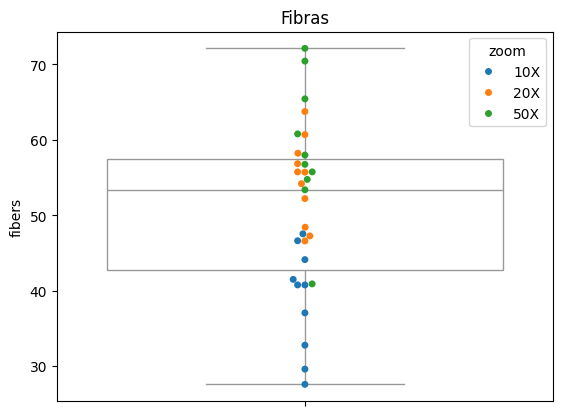

In [45]:
df['zoom'] = df['Image Paths'].str.split('/', expand=True).iloc[:,2].str.replace('x','X').str[:3] # Considero 20x = 20X (mirar X)
sns.boxplot(data=df, y='fibers', color='white')
sns.swarmplot(data=df, y='fibers', hue='zoom')
plt.title('Fibras')
plt.show()

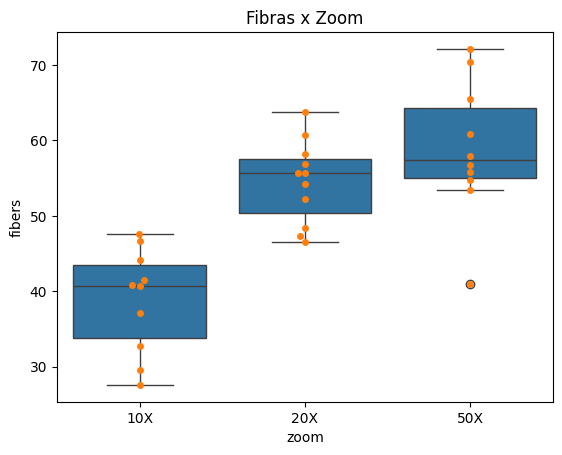

In [46]:
plt.title('Fibras x Zoom')
sns.boxplot(data=df, x='zoom', y='fibers')
sns.swarmplot(data=df, x='zoom', y='fibers')
plt.show()

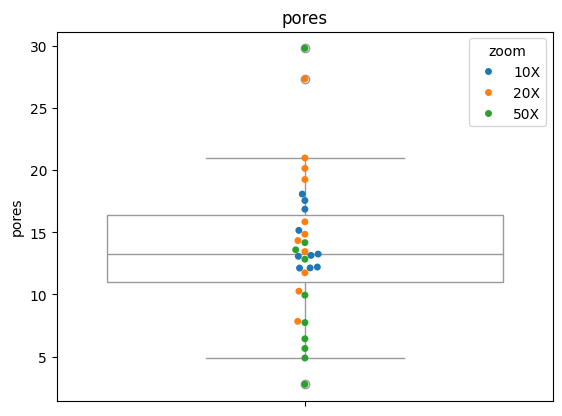

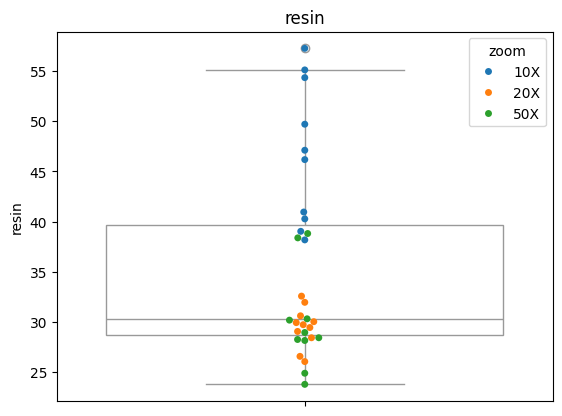

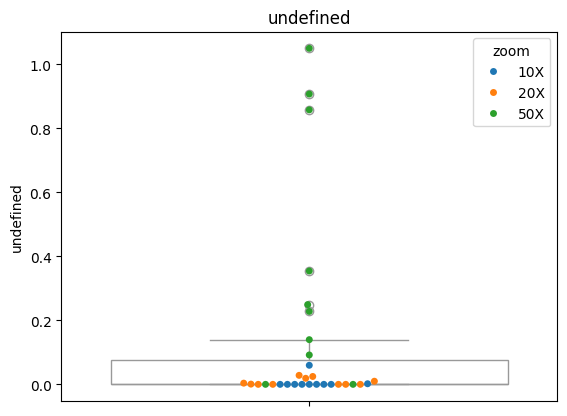

In [47]:
for componente in ['pores', 'resin', 'undefined']:
  sns.boxplot(data=df, y=componente, color='white')
  sns.swarmplot(data=df, y=componente, hue='zoom')
  plt.title(componente)
  plt.show()

In [48]:
df[['zoom','fibers','pores','resin','undefined']].groupby('zoom').describe().T

zoom                   10X        20X        50X
fibers    count  10.000000  11.000000  10.000000
          mean   38.835311  54.510807  58.826114
          std     6.914041   5.508645   9.072483
          min    27.592014  46.592351  40.905527
          25%    33.848850  50.311584  55.001386
          50%    40.767409  55.711757  57.361762
          75%    43.466001  57.528381  64.263829
          max    47.537664  63.749373  72.122492
pores     count  10.000000  11.000000  10.000000
          mean   14.350849  15.995195  10.775217
          std     2.354709   5.563056   7.742553
          min    12.116030   7.828414   2.760899
          25%    12.414605  12.587842   5.842858
          50%    13.189429  14.837191   8.832658
          75%    16.427409  19.687862  13.397594
          max    18.071422  27.332706  29.794560
resin     count  10.000000  11.000000  10.000000
          mean   46.807702  29.486199  30.011015
          std     7.116453   1.975421   4.974093
          min    38.172213  26.050347  23.782022
          25%    40.435487  28.737341  28.176034
          50%    46.636333  29.723573  28.684872
          75%    53.176493  30.317202  30.276681
          max    57.254871  32.570602  38.807195
undefined count  10.000000  11.000000  10.000000
          mean    0.006139   0.007799   0.387654
          std     0.018778   0.010922   0.397822
          min     0.000000   0.000000   0.000000
          25%     0.000000   0.000000   0.103721
          50%     0.000000   0.000723   0.238450
          75%     0.000000   0.014323   0.731638
          max     0.059558   0.028115   1.049769

In [49]:
df.groupby('zoom').agg(
    fibers_Promedio=('fibers', 'mean'),
    fibers_Desvio=('fibers', 'std'),
    pores_Promedio=('pores', 'mean'),
    pores_Desvio=('pores', 'std'),
    resin_Promedio=('resin', 'mean'),
    resin_Desvio=('resin', 'std'),
    undefined_Promedio=('undefined', 'mean'),
    undefined_Desvio=('undefined', 'std')
)

,fibers_Promedio,fibers_Desvio,pores_Promedio,pores_Desvio,resin_Promedio,resin_Desvio,undefined_Promedio,undefined_Desvio
zoom,,,,,,,,
10X,38.835311,6.914041,14.350849,2.354709,46.807702,7.116453,0.006139,0.018778
20X,54.510807,5.508645,15.995195,5.563056,29.486199,1.975421,0.007799,0.010922
50X,58.826114,9.072483,10.775217,7.742553,30.011015,4.974093,0.387654,0.397822


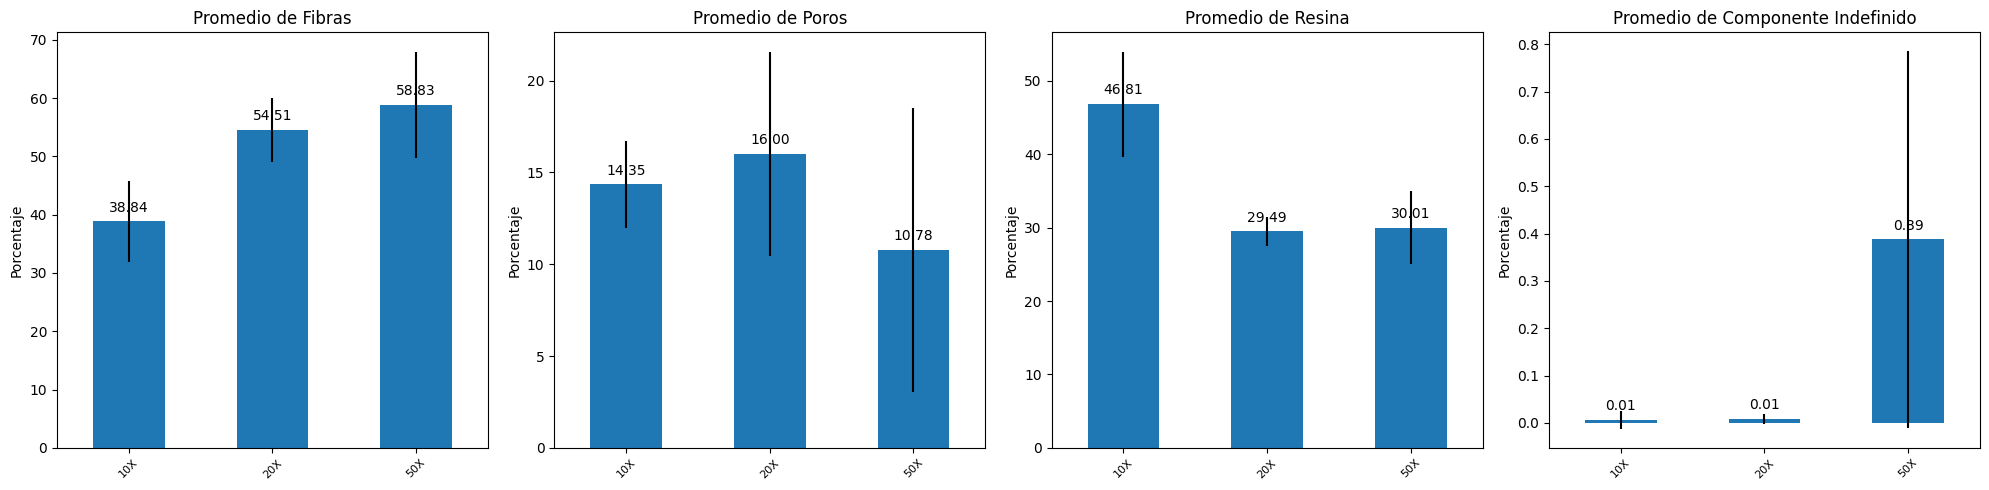

In [51]:
avg_components = df.groupby('zoom')[['fibers', 'pores', 'resin', 'undefined']].mean()
std_components = df.groupby('zoom')[['fibers', 'pores', 'resin', 'undefined']].std()

# Define the desired order of folders
desired_order = ['10X', '20X', '50X']

# Reindex the DataFrame to apply the desired order
avg_components = avg_components.reindex(desired_order)
std_components = std_components.reindex(desired_order)

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), sharey=False)

components = ['fibers', 'pores', 'resin', 'undefined']
titles = ['Promedio de Fibras', 'Promedio de Poros', 'Promedio de Resina', 'Promedio de Componente Indefinido']

for i, component in enumerate(components):
    ax = avg_components[component].plot(
        kind='bar',
        ax=axs[i],
        rot=45,
        yerr=std_components[component]  # Add error bars using standard deviation
    )
    axs[i].set_title(titles[i])
    axs[i].set_xlabel('')
    axs[i].set_ylabel('Porcentaje')
    axs[i].tick_params(axis='x', labelsize=8)  # Adjust x-axis label font size

    # Add annotations on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points')

plt.tight_layout()
plt.show()